# E11 Paper-Condition Diagnostics

### Problem

This notebook directly tests the layerwise condition behind recent spectral-update theory. For a ten-factor matrix factorization model

$$\widehat X=W_1W_2\cdots W_{10},\qquad g(W_{1:10})=\frac{1}{2d^2}\|W_1W_2\cdots W_{10}-X^\star\|_F^2,$$

each update has adjacent factors acting as incoming and outgoing activations. The theory predicts that spectral updates should be more favourable when

$$\frac{\|G\|_*^2/\|G\|_F^2}{\operatorname{srank}(A)}$$

is large. Here $G$ is the block gradient and $A$ is the corresponding activation/factor proxy.

The goal is not to rank optimizers directly. The goal is to test whether this condition score predicts when Muon-family updates help in the deeper factorized model.


## Implementation Details: Skip Unless Modifying The Experiment

The code below follows the existing notebook style: experiment setup, run grid, worker definition, result table, and plotting live in the notebook. It reuses `problems.MatrixFactorization`, `optimizers`, `util.run_experiments`, and `util.diagnostics`.

In [1]:
import math
import os
import pathlib
import sys
import time
from itertools import product

for name in ["OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"]:
    os.environ.setdefault(name, "1")

import IPython.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT = pathlib.Path.cwd().resolve()
if not (PROJECT / "problems").exists():
    PROJECT = PROJECT.parent.resolve()
sys.path.insert(0, str(PROJECT))

import optimizers
import problems.MatrixConstruction
import problems.MatrixFactorization
import problems.MatrixSensing
import util
import util.diagnostics

torch.set_default_dtype(torch.float64)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

print(f"project = {PROJECT}")
print(f"torch   = {torch.__version__}")


project = /Users/tianyangliu/Documents/Workspace/MUONexperiment
torch   = 2.11.0


### Parameters And Runs

In [2]:
NOTEBOOK_ID = "E11 paper-condition diagnostics"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE_NAME = "float64"
ALGOS = ["Muon-Exact", "Muon-NS-1", "NormalizedSGD", "SpectralNormSGD", "Adam", "SGD"]
SEEDS = list(range(5))
SMOKE_TEST = False
SMOKE_TEST_MAX_STEPS = 10
FULL_ITERS = 800

BASE_SPEC = dict(
    problem="MatrixFactorization",
    d=60,
    rank=5,
    lr=0.01,
    iters=SMOKE_TEST_MAX_STEPS if SMOKE_TEST else FULL_ITERS,
    diagnostic_every=1 if SMOKE_TEST else 20,
    early_stop=True,
    early_stop_min_steps=100,
    early_stop_patience=20,
    early_stop_min_delta=1e-8,
    device_type=DEVICE.type,
    dtype_name=DTYPE_NAME,
)

SETTINGS = [
    dict(setting="MF-balanced", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-2, right_scale=1e-2),
    dict(setting="MF-tiny", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1e-4),
    dict(setting="MF-overparam", spectrum="hard-cutoff", kappa=1.0, factor_rank=20, left_scale=1e-2, right_scale=1e-2),
    dict(setting="MF-imbalanced", spectrum="hard-cutoff", kappa=1.0, factor_rank=5, left_scale=1e-4, right_scale=1.0),
    dict(setting="MF-ill-conditioned", spectrum="exponential-decay", kappa=100.0, factor_rank=5, left_scale=1e-2, right_scale=1e-2),
]

NUM_WORKERS = min(8, os.cpu_count() or 1)
JOBLIB_BACKEND = "loky"

runs = pd.DataFrame([
    {**BASE_SPEC, **setting, "algo": algo, "seed": seed}
    for setting in SETTINGS
    for algo in ALGOS
    for seed in SEEDS
])
runs.insert(0, "run_id", range(len(runs)))
print(f"device={DEVICE}, workers={NUM_WORKERS}, backend={JOBLIB_BACKEND}")
print(f"smoke_test={SMOKE_TEST}, steps_per_run={BASE_SPEC['iters']}")
print(f"runs={len(runs)}, max_total_steps={len(runs) * BASE_SPEC['iters']}")
IPython.display.display(runs)


device=cpu, workers=8, backend=loky
smoke_test=False, steps_per_run=800
runs=150, max_total_steps=120000


,run_id,problem,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,...,device_type,dtype_name,setting,spectrum,kappa,factor_rank,left_scale,right_scale,algo,seed
0,0,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,0
1,1,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,1
2,2,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,2
3,3,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,3
4,4,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-balanced,hard-cutoff,1.0,5,0.01,0.01,Muon-Exact,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,145,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,0
146,146,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,1
147,147,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,2
148,148,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,cpu,float64,MF-ill-conditioned,exponential-decay,100.0,5,0.01,0.01,SGD,3


### Pseudocode

```text
for each setting, optimizer, seed:
    build a MatrixFactorization problem using the repo problem constructor
    initialise L and R with the requested scales
    at diagnostic steps:
        compute gradients G_L and G_R
        compute ||G||_*^2 / ||G||_F^2
        compute stable ranks of opposite factors R and L
        condition_score = average gradient_score / average activation_stable_rank
        record update effective rank, descent alignment, relative step size
    return long per-step table
```

### Worker Definition

In [ ]:
def dtype_from_name(dtype_name):
    dtype = getattr(torch, dtype_name)
    if not isinstance(dtype, torch.dtype):
        raise ValueError(f"unknown torch dtype: {dtype_name}")
    return dtype


def configure_torch(dtype):
    torch.set_default_dtype(dtype)
    torch.set_num_threads(1)
    try:
        torch.set_num_interop_threads(1)
    except RuntimeError:
        pass


def make_generator(seed, device):
    try:
        return torch.Generator(device=device).manual_seed(int(seed))
    except Exception:
        return torch.Generator().manual_seed(int(seed))


def randn(shape, seed, device, dtype):
    shape = tuple(int(dim) for dim in shape)
    return torch.randn(shape, generator=make_generator(seed, device), device=device, dtype=dtype)


def make_optimizer(algo, params, lr, rank=None):
    if algo == "Muon" and hasattr(torch.optim, "Muon"):
        try:
            return torch.optim.Muon(params, lr=lr, weight_decay=0.0, momentum=0.9, nesterov=False, ns_steps=5)
        except TypeError:
            pass
    if algo == "Muon":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-Exact":
        return optimizers.MuonExact(params, lr=lr, variant="exact")
    if algo == "Muon-NS-1":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=1)
    if algo == "Muon-NS-5":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=5)
    if algo == "Muon-NS-10":
        return optimizers.MuonExact(params, lr=lr, variant="newton_schulz", ns_steps=10)
    if algo == "Muon-Truncated":
        return optimizers.MuonExact(params, lr=lr, variant="truncated", rank=rank)
    if algo == "Muon-RandSVD":
        return optimizers.MuonExact(params, lr=lr, variant="randsvd", rank=rank)
    if algo == "NormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "SpectralNormSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="spectral", momentum=0.0)
    if algo == "LayerwiseNormalizedSGD":
        return optimizers.NormalizedSGD(params, lr=lr, norm_type="fro", momentum=0.0)
    if algo == "Shampoo":
        return optimizers.Shampoo(params, lr=lr)
    if algo == "Adam":
        return torch.optim.Adam(params, lr=lr)
    if algo == "SGD":
        return torch.optim.SGD(params, lr=lr)
    raise ValueError(f"unknown optimizer: {algo}")


def nuclear_fro_ratio(matrix, epsilon=1e-12):
    singular_values = torch.linalg.svdvals(matrix.detach())
    numerator = singular_values.sum().square()
    denominator = singular_values.square().sum().clamp_min(epsilon)
    return float((numerator / denominator).detach().cpu())


def relative_update_diagnostics(params_before, params_after, gradients):
    updates = [after.detach() - before.detach() for before, after in zip(params_before, params_after)]
    return {
        "descent_alignment": util.diagnostics.descent_alignment(gradients, updates),
        "relative_step_size": util.diagnostics.relative_step_size(params_before, updates),
        **util.diagnostics.aggregate_matrix_diagnostics(updates, prefix="update"),
        **util.diagnostics.aggregate_matrix_diagnostics(gradients, prefix="grad"),
    }


def summarize_last_rows(runs, group_columns):
    ordered = runs.sort_values(["run_id", "step"])
    return ordered.groupby(group_columns, as_index=False, observed=True).tail(1).reset_index(drop=True)

def mf_condition_scores(factors, target):
    for tensor in factors:
        if tensor.grad is not None:
            tensor.grad = None
    loss = problems.MatrixFactorization.matrix_factorization_loss(*factors, target)
    loss.backward()
    gradients = [factor.grad.detach().clone() for factor in factors]
    for tensor in factors:
        tensor.grad = None
    gradient_score = float(np.mean([nuclear_fro_ratio(grad) for grad in gradients]))
    activation_stable_rank = float(np.mean([util.diagnostics.stable_rank(factor) for factor in factors]))
    return {
        "condition_score": gradient_score / max(activation_stable_rank, 1e-12),
        "gradient_nuclear_fro_ratio": gradient_score,
        "activation_stable_rank": activation_stable_rank,
    }


def single_run(run):
    dtype = dtype_from_name(run["dtype_name"])
    configure_torch(dtype)
    device = torch.device(run["device_type"])
    problem = problems.MatrixFactorization.make_matrix_factorization_problem(
        run["d"], run["rank"], spectrum=run["spectrum"], kappa=run["kappa"], seed=run["seed"],
        device=device, dtype=dtype, factor_rank=run["factor_rank"],
        num_factors=int(run.get("num_factors", 10)),
    )
    factor_inits = problems.MatrixFactorization.initialize_factor_chain(
        int(run["d"]), int(run["factor_rank"]), seed=int(run["seed"]) + 10, device=device, dtype=dtype,
        num_factors=int(run.get("num_factors", 10)),
        left_scale=float(run["left_scale"]), right_scale=float(run["right_scale"]),
    )
    factors = [factor.requires_grad_(True) for factor in factor_inits]
    params = factors
    opt = make_optimizer(run["algo"], params, run["lr"], rank=run["rank"])
    initial_loss = float(problem.loss(*factors).detach().cpu())
    best_loss = initial_loss
    wait = 0
    rows = []
    start = time.perf_counter()
    stop_reason = "max_steps"
    for step in range(int(run["iters"]) + 1):
        do_diag = (step == 0) or (step == run["iters"]) or (step % int(run["diagnostic_every"]) == 0)
        if do_diag:
            loss_value = float(problem.loss(*factors).detach().cpu())
            estimate = problem.estimate(*factors)
            recovery = util.diagnostics.relative_matrix_error(estimate, problem.target)
            cond = mf_condition_scores(factors, problem.target)
            rows.append({**run, "step": step, "initial_loss": initial_loss, "loss": loss_value,
                         "best_loss": best_loss, "recovery_error": recovery,
                         "balancedness": util.diagnostics.balancedness(*factors),
                         "top_sv_error": util.diagnostics.top_singular_value_error(estimate, problem.target, k=run["rank"]),
                         **cond, "elapsed_s": time.perf_counter() - start, "stop_reason": stop_reason})
        if step == run["iters"]:
            break
        loss = problem.loss(*factors)
        loss.backward()
        params_before = [p.detach().clone() for p in params]
        grads = [p.grad.detach().clone() for p in params]
        opt.step()
        params_after = [p.detach().clone() for p in params]
        for p in params:
            p.grad = None
        if do_diag and rows:
            rows[-1].update(relative_update_diagnostics(params_before, params_after, grads))
        current = float(problem.loss(*factors).detach().cpu())
        if best_loss - current > run["early_stop_min_delta"]:
            best_loss = current
            wait = 0
        else:
            wait += 1
        if run["early_stop"] and step >= run["early_stop_min_steps"] and wait >= run["early_stop_patience"]:
            stop_reason = "early_stop"
            break
    return pd.DataFrame(rows)


## Results

In [4]:
runs = util.run_experiments(
    runs, single_run, num_workers=NUM_WORKERS, backend=JOBLIB_BACKEND,
    algo_order=ALGOS, sort_columns=("run_id", "step"), desc=NOTEBOOK_ID,
)
IPython.display.display(runs)


E11 paper-condition diagnostics:   0%|          | 0/150 [00:00<?, ?run/s]

E11 paper-condition diagnostics:   1%|          | 1/150 [00:04<10:13,  4.11s/run]

E11 paper-condition diagnostics:  32%|███▏      | 48/150 [00:05<00:08, 12.27run/s]

E11 paper-condition diagnostics:  71%|███████▏  | 107/150 [00:06<00:01, 24.77run/s]

E11 paper-condition diagnostics: 100%|██████████| 150/150 [00:06<00:00, 23.09run/s]

,run_id,problem,d,rank,lr,iters,diagnostic_every,early_stop,early_stop_min_steps,early_stop_patience,...,descent_alignment,relative_step_size,update_fro_norm,update_op_norm,update_effective_rank,update_stable_rank,grad_fro_norm,grad_op_norm,grad_effective_rank,grad_stable_rank
0,0,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,0.823213,1.301770e-01,3.162278e-02,1.000000e-02,5.000000,5.000000,0.000019,0.000010,3.856973,1.946842
1,0,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,-0.834641,3.977786e-02,1.425852e-01,6.075353e-02,4.887080,2.756246,0.000293,0.000113,4.803112,3.358025
2,0,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,0.252891,2.924494e-02,9.289582e-02,3.560110e-02,4.940118,3.405993,0.000059,0.000027,4.825765,2.381108
3,0,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,-0.083075,1.002715e-02,3.179162e-02,1.720839e-02,4.462484,1.705551,0.000025,0.000013,4.639247,1.830399
4,0,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,0.176954,9.622826e-03,3.044588e-02,1.603586e-02,4.427046,1.802931,0.000024,0.000014,4.014832,1.565398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1819,149,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,1.000000,4.873900e-07,1.234942e-07,7.431035e-08,2.966202,0.007625,0.000012,0.000007,2.966202,1.381516
1820,149,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,1.000000,4.874039e-07,1.234978e-07,7.431282e-08,2.966174,0.007626,0.000012,0.000007,2.966174,1.381506
1821,149,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,1.000000,4.874177e-07,1.235014e-07,7.431528e-08,2.966146,0.007626,0.000012,0.000007,2.966146,1.381495
1822,149,MatrixFactorization,60,5,0.01,800,20,True,100,20,...,1.000000,4.874316e-07,1.235050e-07,7.431775e-08,2.966118,0.007627,0.000012,0.000007,2.966118,1.381485


### Individual Loss Curves

Each figure below keeps every `run_id` as a separate line. Color encodes optimizer; panel labels encode the experiment setting.

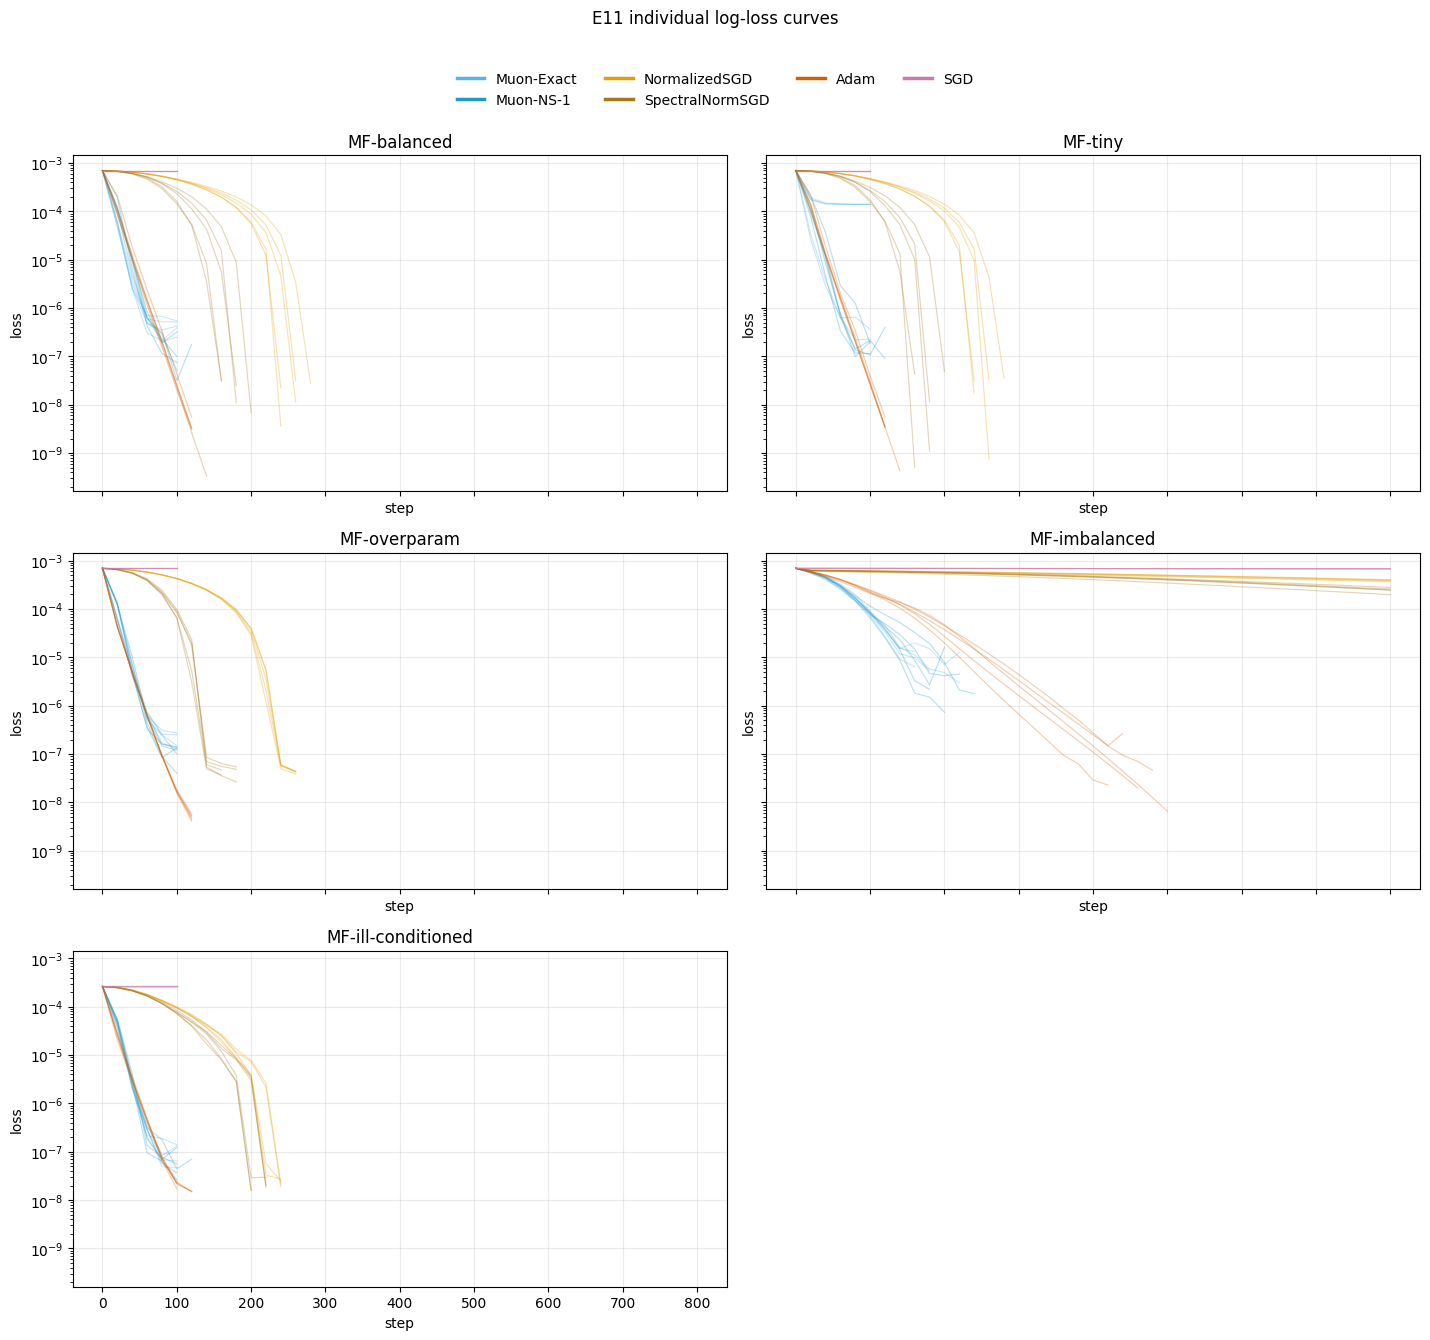

In [5]:
import plotting
from matplotlib.lines import Line2D


def plot_individual_loss_curves(frame, panel_column, *, panel_order=None, title_prefix="Individual loss curves"):
    plot_frame = frame[np.isfinite(frame["loss"])].copy()
    if plot_frame.empty:
        print("No finite loss values to plot.")
        return None, None
    plot_frame["loss_plot"] = plot_frame["loss"].clip(lower=1e-300)
    panels = list(panel_order) if panel_order is not None else sorted(plot_frame[panel_column].dropna().unique())
    ncols = min(2, max(1, len(panels)))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2 * ncols, 4.2 * nrows), sharex=True, sharey=True, squeeze=False)
    axes_flat = axes.ravel()
    for ax, panel in zip(axes_flat, panels):
        sub = plot_frame[plot_frame[panel_column] == panel].sort_values(["run_id", "step"])
        run_count = max(1, sub["run_id"].nunique())
        alpha = max(0.04, min(0.30, 18.0 / run_count))
        for _, group in sub.groupby("run_id", observed=True, sort=False):
            algo = str(group["algo"].iloc[0])
            ax.plot(
                group["step"],
                group["loss_plot"],
                color=plotting.algorithm_color(algo),
                linewidth=0.85,
                alpha=alpha,
            )
        ax.set_title(str(panel))
        ax.set_xlabel("step")
        ax.set_ylabel("loss")
        ax.set_yscale("log")
        ax.grid(alpha=0.25)
    for ax in axes_flat[len(panels):]:
        ax.axis("off")
    algos = [algo for algo in ALGOS if algo in set(plot_frame["algo"].astype(str))]
    handles = [Line2D([0], [0], color=plotting.algorithm_color(algo), linewidth=2.5, label=algo) for algo in algos]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=min(4, len(handles)), bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle(title_prefix, y=1.06 if handles else 1.02)
    fig.tight_layout()
    return fig, axes

fig, axes = plot_individual_loss_curves(runs, "setting", panel_order=[setting["setting"] for setting in SETTINGS], title_prefix="E11 individual log-loss curves")
plt.show()


### Result Tables

In [6]:
run_summary = summarize_last_rows(runs, ["run_id"])
summary = run_summary.groupby(["setting", "algo"], as_index=False, observed=True).agg(
    median_recovery=("recovery_error", "median"),
    median_condition_score=("condition_score", "median"),
    median_gradient_score=("gradient_nuclear_fro_ratio", "median"),
    median_activation_stable_rank=("activation_stable_rank", "median"),
    median_balancedness=("balancedness", "median"),
    median_top_sv_error=("top_sv_error", "median"),
)
IPython.display.display(summary.sort_values(["setting", "median_recovery"]))


,setting,algo,median_recovery,median_condition_score,median_gradient_score,median_activation_stable_rank,median_balancedness,median_top_sv_error
0,MF-balanced,Adam,0.002143,1.077642,4.284488,3.965957,0.195485,0.000308
3,MF-balanced,NormalizedSGD,0.005671,0.377680,1.880073,4.977958,0.002124,0.005667
5,MF-balanced,SpectralNormSGD,0.005978,0.367868,1.831290,4.976245,0.002322,0.005977
2,MF-balanced,Muon-NS-1,0.011983,0.660620,3.074609,4.654129,0.056033,0.009384
1,MF-balanced,Muon-Exact,0.024670,0.950388,4.250792,4.543156,0.087583,0.022810
4,MF-balanced,SGD,1.000111,1.007635,3.547418,3.532077,0.168146,0.994168
6,MF-ill-conditioned,Adam,0.007656,0.308138,0.781271,2.498960,0.140729,0.004776
11,MF-ill-conditioned,SpectralNormSGD,0.008556,0.136516,0.344025,2.520028,0.003624,0.004755
9,MF-ill-conditioned,NormalizedSGD,0.009079,0.360815,0.906754,2.520308,0.005462,0.006333
8,MF-ill-conditioned,Muon-NS-1,0.014632,1.195278,2.987652,2.519156,0.090954,0.006044


### Condition Score Vs Muon Advantage

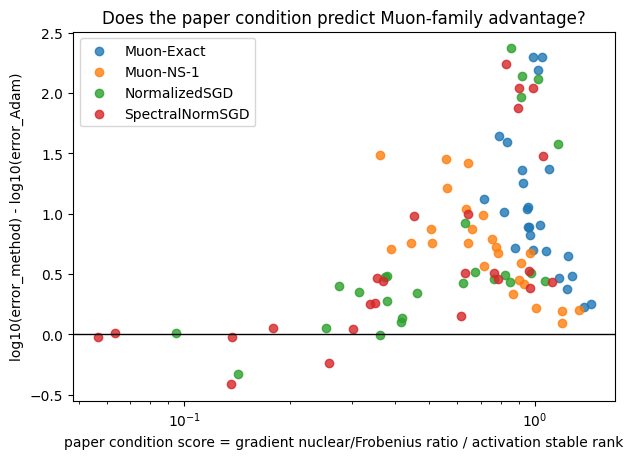

In [7]:
baseline = run_summary[run_summary["algo"] == "Adam"][["setting", "seed", "recovery_error"]].rename(columns={"recovery_error": "adam_error"})
muon_rows = run_summary[run_summary["algo"].isin(["Muon-Exact", "Muon-NS-1", "NormalizedSGD", "SpectralNormSGD"])].merge(baseline, on=["setting", "seed"], how="inner")
muon_rows["log_error_gap_vs_adam"] = np.log10(muon_rows["recovery_error"].clip(lower=1e-12)) - np.log10(muon_rows["adam_error"].clip(lower=1e-12))
fig, ax = plt.subplots(figsize=(7, 4.8))
for algo, group in muon_rows.groupby("algo", observed=True):
    ax.scatter(group["condition_score"], group["log_error_gap_vs_adam"], label=algo, alpha=0.8)
ax.axhline(0.0, color="black", linewidth=1)
ax.set_xscale("log")
ax.set_xlabel("paper condition score = gradient nuclear/Frobenius ratio / activation stable rank")
ax.set_ylabel("log10(error_method) - log10(error_Adam)")
ax.set_title("Does the paper condition predict Muon-family advantage?")
ax.legend()
plt.show()


### Reading The Result

This notebook supports the theory if high condition scores align with negative Muon-vs-Adam error gaps. If no such trend appears, the current settings do not yet verify the layerwise condition and the next step should be to check learning-rate calibration and early-training condition scores.

### Hypothesis Verdict Table

| hypothesis | evidence | supported? | caveat |
|---|---|---|---|
| The spectral-update condition score should predict Muon-family advantage. | The condition-score plot compares Muon-vs-Adam recovery gaps against the measured score across factorization settings. | Partial | The current score is an averaged proxy over factors, and optimizer hyperparameters are not retuned per setting. |
| High scores alone should not be treated as a sufficient success criterion. | The result table includes recovery, condition score, update diagnostics, and loss, so score can be checked against actual recovery. | Yes | The table supports diagnostic use of the score more strongly than a universal theorem-level claim. |
